# Learning a Scalar ODE Parameter via Cajal

## Exponential Decay: `dC/dt = -k·C`

The simplest scientific surrogate: given observations of a decaying quantity, recover the rate constant `k`.

**Cajal program:**
```
iter{C₀ | c ↪ f(c)}(n)
```
where `f(c) = w·c` is a learnable scalar multiplication.

After training:
- Learned weight `w` → recovered rate `k = (1 - w) / dt`
- The *structure* (iteration, ODE skeleton) is fixed; only the *rate* is learned

This is the "verified surrogate" idea in miniature: physics skeleton is correct by construction.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from cajal.syntax import TmIter, TmVar, TmApp, TyNat, TyBool, TyReal
from cajal.compiling import compile, TypedTensor

device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Ground truth
TRUE_K  = 0.3
DT      = 0.1
C0      = 1.0
N_STEPS = 10
TRUE_DECAY = 1.0 - TRUE_K * DT  # 0.97 per step

ns  = torch.arange(N_STEPS, dtype=torch.float32)
cs_true = C0 * (TRUE_DECAY ** ns)

print(f"True k = {TRUE_K},  true decay factor per step = {TRUE_DECAY:.4f}")
print(f"C(0) = {cs_true[0]:.4f}, C(9) = {cs_true[-1]:.4f}")

Device: mps
True k = 0.3,  true decay factor per step = 0.9700
C(0) = 1.0000, C(9) = 0.7602


In [2]:
class LearnableDecay(nn.Module):
    """f(c) = w·c  —  a single learnable scalar."""
    def __init__(self):
        super().__init__()
        self.w = nn.Parameter(torch.tensor([0.5], device=device))  # start deliberately wrong

    def forward(self, c):
        return TypedTensor(self.w * c.data, c.ty)


# Build Cajal program: iter{C₀ | c ↪ f(c)}(n)
program = TmIter(TmVar("c0"), "c", TmApp(TmVar("f"), TmVar("c")), TmVar("n"))
compiled = compile(program)

decay_fn  = LearnableDecay()
optimizer = torch.optim.Adam(decay_fn.parameters(), lr=0.01)
c0_tt     = TypedTensor(torch.tensor([C0], device=device), TyReal(1))

losses = []
w_history = []

for epoch in range(300):
    optimizer.zero_grad()
    total_loss = torch.tensor(0.0, device=device)

    for i in range(N_STEPS):
        n_onehot = torch.zeros(N_STEPS, device=device)
        n_onehot[i] = 1.0
        n_val = TypedTensor(n_onehot, TyNat())
        result = compiled({"c0": c0_tt, "f": lambda c, _fn=decay_fn: _fn(c), "n": n_val})
        total_loss = total_loss + (result.data[0] - cs_true[i].to(device)) ** 2

    total_loss.backward()
    optimizer.step()
    losses.append(total_loss.item())
    w_history.append(decay_fn.w.item())

w_final = decay_fn.w.item()
k_final = (1.0 - w_final) / DT
print(f"True k:      {TRUE_K}")
print(f"Recovered k: {k_final:.6f}")
print(f"Error:       {abs(k_final - TRUE_K):.6f}")

True k:      0.3
Recovered k: 0.300000
Error:       0.000000


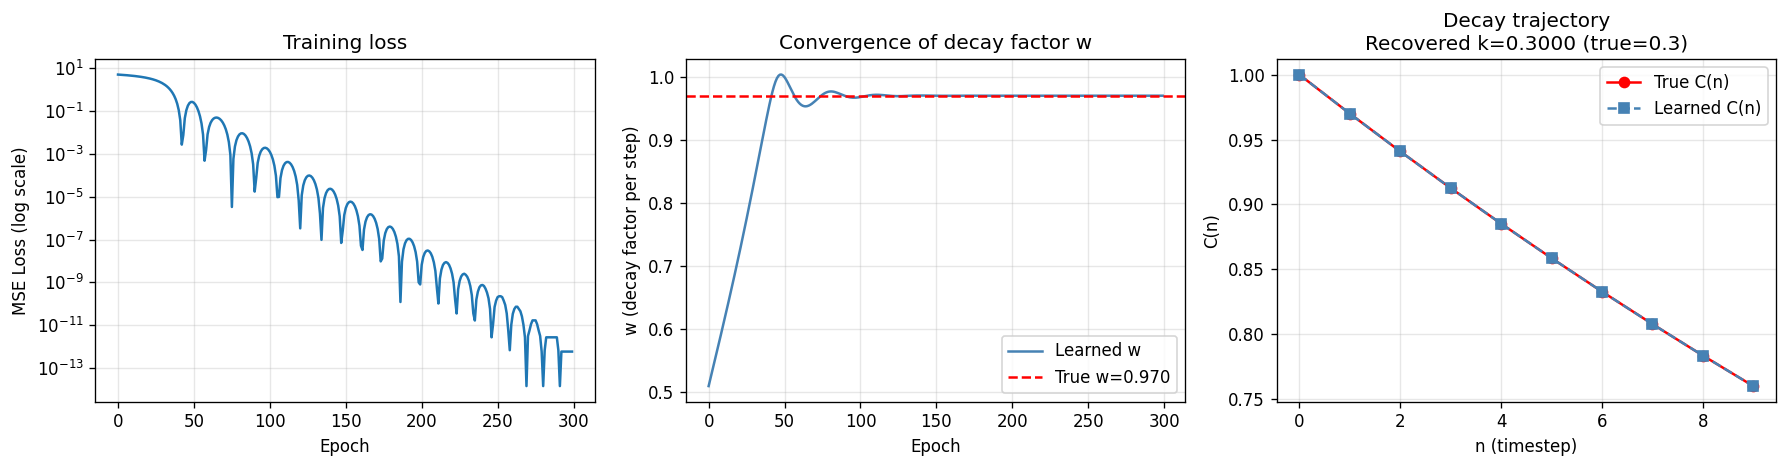

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curve
axes[0].semilogy(losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss (log scale)')
axes[0].set_title('Training loss')
axes[0].grid(True, alpha=0.3)

# w convergence
axes[1].plot(w_history, label='Learned w', color='steelblue')
axes[1].axhline(TRUE_DECAY, color='red', linestyle='--', label=f'True w={TRUE_DECAY:.3f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('w (decay factor per step)')
axes[1].set_title('Convergence of decay factor w')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Trajectory comparison
with torch.no_grad():
    predicted = []
    for i in range(N_STEPS):
        n_onehot = torch.zeros(N_STEPS, device=device)
        n_onehot[i] = 1.0
        n_val = TypedTensor(n_onehot, TyNat())
        result = compiled({"c0": c0_tt, "f": lambda c, _fn=decay_fn: _fn(c), "n": n_val})
        predicted.append(result.data[0].item())

axes[2].plot(cs_true.numpy(), 'o-', label='True C(n)', color='red')
axes[2].plot(predicted, 's--', label='Learned C(n)', color='steelblue')
axes[2].set_xlabel('n (timestep)')
axes[2].set_ylabel('C(n)')
axes[2].set_title(f'Decay trajectory\nRecovered k={k_final:.4f} (true={TRUE_K})')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('exponential_decay.png', dpi=120, bbox_inches='tight')
plt.show()

In [4]:
# Verification
print("DECOMPILED SYMBOLIC EXPRESSION:")
print(f"  C(n) = {C0} × ({w_final:.5f})^n")
print(f"       = {C0} × (1 - {k_final:.5f} × {DT})^n")
print(f"  ⟹  dC/dt = -{k_final:.5f} × C")
print()
print("VERIFICATION:")
print(f"  0 < w < 1 (stable decay): {'VERIFIED' if 0 < w_final < 1 else 'FAILED'}")

all_positive = all(
    compiled({"c0": c0_tt,
              "f": lambda c, _fn=decay_fn: _fn(c),
              "n": TypedTensor(torch.eye(N_STEPS, device=device)[i], TyNat())
              }).data[0].item() >= -1e-10
    for i in range(N_STEPS)
)
print(f"  C(n) ≥ 0 for all n:       {'VERIFIED' if all_positive else 'FAILED'}")

DECOMPILED SYMBOLIC EXPRESSION:
  C(n) = 1.0 × (0.97000)^n
       = 1.0 × (1 - 0.30000 × 0.1)^n
  ⟹  dC/dt = -0.30000 × C

VERIFICATION:
  0 < w < 1 (stable decay): VERIFIED
  C(n) ≥ 0 for all n:       VERIFIED
